In [5]:
# Set workspace
import sys
import os
workspace_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Libraries

In [33]:
# Libraries
import pandas as pd
import numpy as np
import gpxpy
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [7]:
# Other helpers

from helper_functions.gpx_to_tabular import (
    SLOPE_CATEGORIES,
    classify_slope,
    gpx_to_tabular,
    plot_course_profile
)

from helper_functions.sector_data_cleanup import (
    clean_runner_race_sector_data,
    apply_rest_only_checkpoint_correction,
    add_sector_distance_features,
    build_sector_boundaries,
    assign_course_points_to_sectors,
    build_course_sector_elevation_aggregation,
    add_sector_elevation_features,
)

---
# Data

UTMB (2025) GPX to tabular data

In [8]:
# Import UTMB GPX

gpx_file_path = "utmb_2025_course.gpx"
with open(gpx_file_path, "r") as f:
    utmb_gpx = gpxpy.parse(f)

In [9]:
# UTMB GPX to Tabular
utmb_course_df = gpx_to_tabular(utmb_gpx)

Sector data - (2022, 2023, 2024, 2025)

In [10]:
# Get sector data for UTMB

# Dictionary | key = year
utmb_sector_data_dict = dict()
for year in [2022, 2023, 2024, 2025]:

    with open(os.path.join("..", "pacing_strategy", "data", f"utmb_{year}_sector_data.pkl"), "rb") as f:
        utmb_year_sector_data_dict = pickle.load(f)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_sector_data_dict[year] = utmb_year_sector_data_dict

Data for year 2022 fetched and loaded successfully
Data for year 2023 fetched and loaded successfully
Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


In [11]:
# Choose one representative runner with complete sector data for each year 
representative_sector_data = pd.DataFrame()
for year in utmb_sector_data_dict.keys():
    for runner_bib in utmb_sector_data_dict[year].keys():
        year_runner_bib_sector_data = utmb_sector_data_dict[year][runner_bib].copy()

        runner_is_finisher = (
            year_runner_bib_sector_data
            .loc[
                lambda df: df["sector_checkpoint_id"] == df["sector_checkpoint_id"].max(),
                "sector_arrival_time",
            ]
            .notna()
            .any()
        )

        runner_has_complete_sector_times = (
            year_runner_bib_sector_data
            .loc[lambda df: df["sector_checkpoint_id"] != 0, "sector_time"]
            .notna()
            .all()
        )


        if runner_is_finisher and runner_has_complete_sector_times :
            representative_sector_data = pd.concat([
                representative_sector_data, 
                year_runner_bib_sector_data.assign(
                    year = year,
                    representative_runner_bib = runner_bib
                )
            ], ignore_index = True)

            break

In [27]:
# About - sectors
representative_sector_data_summary = (
    representative_sector_data
    .groupby("year")
    .aggregate(
        number_of_sectors = ("sector_checkpoint_id", "nunique"),
        sector_checkpoint_ids = ("sector_checkpoint_id", lambda x: [int(value) for value in sorted(x.unique())]),
        representative_runner_bib = ("representative_runner_bib", "first"),
    )
    .reset_index()
)

for _, row in representative_sector_data_summary.iterrows():
    print(f"\nYear: {row['year']}")
    print("----------------------------------------")
    print(f"Representative runner bib: {row['representative_runner_bib']}")
    print(f"Number of sectors: {row['number_of_sectors']}")
    print(f"Sector checkpoint IDs: {row['sector_checkpoint_ids']}")

# Common and Unique sectors by years
sector_ids_by_year = (
    representative_sector_data
    .assign(year = lambda df: df["year"].astype(int))
    .groupby("year")["sector_checkpoint_id"]
    .apply(lambda s: set(int(x) for x in s.unique()))
)

all_sector_ids = set.union(*sector_ids_by_year.tolist())
common_sector_ids = set.intersection(*sector_ids_by_year.tolist())
not_common_sector_ids = all_sector_ids - common_sector_ids

all_years = sorted(representative_sector_data["year"].astype(int).unique().tolist())
sector_years = (
    representative_sector_data
    .groupby("sector_checkpoint_id")["year"]
    .apply(lambda s: sorted(s.astype(int).unique().tolist()))
)

print("\nAbout common sectors:")
print("----------------------------------------")
print("Common sector IDs across all years: {}".format(sorted(common_sector_ids)))
print("Sector IDs not common to all years, with years present:")
for sector_id in sorted(not_common_sector_ids):
    missing_years = sorted(set(all_years) - set(sector_years[sector_id]))
    print(" - {} -> missing years: {}".format(sector_id, missing_years))


Year: 2022
----------------------------------------
Representative runner bib: 8
Number of sectors: 26
Sector checkpoint IDs: [2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 14, 15, 18, 20, 22, 24, 27, 29, 30, 31, 33, 34, 35, 43, 44, 143]

Year: 2023
----------------------------------------
Representative runner bib: 1
Number of sectors: 25
Sector checkpoint IDs: [2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 14, 15, 18, 19, 20, 22, 24, 27, 30, 31, 33, 34, 35, 44, 144]

Year: 2024
----------------------------------------
Representative runner bib: 1
Number of sectors: 27
Sector checkpoint IDs: [2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 18, 19, 20, 22, 23, 24, 27, 30, 31, 33, 34, 35, 44, 144]

Year: 2025
----------------------------------------
Representative runner bib: 1
Number of sectors: 25
Sector checkpoint IDs: [2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 15, 18, 19, 20, 22, 24, 27, 30, 31, 33, 34, 35, 44, 144]

About common sectors:
----------------------------------------
Common sector IDs across all years: [

---
# Cleanup sector data

Simple cleanup

In [13]:
# Add needed columns for later cleanup
representative_sector_data = (
    representative_sector_data
    .assign(
        race_id = "utmb",
        runner_id = lambda df: df.groupby("year").ngroup() + 1,
        runner_is_finisher = 1,
    )
)

In [14]:
# Add some additional sector description columns
representative_sector_data = clean_runner_race_sector_data(sector_df = representative_sector_data)

In [15]:
# Correct rest only sectors
representative_sector_data = apply_rest_only_checkpoint_correction(sector_df = representative_sector_data)

In [16]:
# Sector absolute and relative distance
representative_sector_data = add_sector_distance_features(sector_df = representative_sector_data)

Connect UTMB tabular course data with Sector data & calculate additional features that were not possible from only sector data

In [17]:
# Build sector boundaries - for connecting with GPX data
sector_boundaries_df = build_sector_boundaries(sector_df = representative_sector_data)

In [18]:
# Aggregate GPX course features by sector, add to sector data and calculate additional sector features (elevation)
course_sector_elevation_df = build_course_sector_elevation_aggregation(
    utmb_course_df = utmb_course_df,
    sector_boundaries_df = sector_boundaries_df
)

representative_sector_data_course_df = add_sector_elevation_features(
    sector_df = representative_sector_data,
    course_sector_agg_df = course_sector_elevation_df,
)

---
# UTMB Course Analysis

Sectors

Repeated sectors decision:
- For analysis: keep sectors year-specific.
- For presentation: create a simplified shared sector label when the repeated checkpoint ID has very similar distance position across years.
    - Treat sector as same if:
        - sector_start_distance_km_range <= 2 km
        - sector_end_distance_km_range <= 2 km
        - sector_distance_km_range <= 2 km
    - Decision 
        - Based on majority of non consistent, we keep sectors year specific always
        - For "about" do average across years for the sector ...

In [19]:
# Working data
display(
    representative_sector_data_course_df[[
        # Identifiers
        "race_id", "year", "sector_checkpoint_id", 
        
        # About
        "sector_is_rest_only",

        # Distance
        "sector_distance_km", "sector_start_distance_km", "sector_end_distance_km",
        "relative_sector_distance", "relative_sector_start_distance", "relative_sector_end_distance",

        # Elevation
        "sector_elevation_gain_m", "sector_elevation_loss_m",
        "relative_sector_elevation_gain", "relative_sector_elevation_loss",
    ]]
)

# Save for later
sector_identifiers = ["race_id", "year", "sector_checkpoint_id",]
sector_about = ["sector_is_rest_only"]
sector_distance = [
    "sector_distance_km", "sector_start_distance_km", "sector_end_distance_km",
    "relative_sector_distance", "relative_sector_start_distance", "relative_sector_end_distance",
]
sector_elevation = [
    "sector_elevation_gain_m", "sector_elevation_loss_m",
    "relative_sector_elevation_gain", "relative_sector_elevation_loss",
]

,race_id,year,sector_checkpoint_id,sector_is_rest_only,sector_distance_km,sector_start_distance_km,sector_end_distance_km,relative_sector_distance,relative_sector_start_distance,relative_sector_end_distance,sector_elevation_gain_m,sector_elevation_loss_m,relative_sector_elevation_gain,relative_sector_elevation_loss
0,utmb,2022,2,False,13.303249,0.000000,13.303249,0.077523,0.000000,0.077523,923.582005,410.632005,0.087880,0.039076
1,utmb,2022,3,False,8.364979,13.303249,21.668228,0.048746,0.077523,0.126270,272.000000,938.400000,0.025881,0.089298
2,utmb,2022,4,False,9.643659,21.668228,31.311887,0.056198,0.126270,0.182467,473.200000,277.800000,0.045026,0.026436
3,utmb,2022,5,False,8.326577,31.311887,39.638463,0.048522,0.182467,0.230990,564.646896,83.646896,0.053727,0.007960
4,utmb,2022,6,False,5.618790,39.638463,45.257253,0.032743,0.230990,0.263733,864.500000,19.700000,0.082259,0.001875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,utmb,2025,33,False,3.998893,144.887000,148.885892,0.022798,0.825997,0.848795,642.000000,142.400000,0.061087,0.013551
99,utmb,2025,34,False,8.143208,148.885892,157.029100,0.046424,0.848795,0.895219,179.000000,745.400000,0.017032,0.070932
100,utmb,2025,35,True,0.000000,157.029100,157.029100,0.000000,0.895219,0.895219,0.000000,0.000000,0.000000,0.000000
101,utmb,2025,44,False,11.277506,157.029100,168.306606,0.064293,0.895219,0.959512,871.800000,817.600000,0.082953,0.077803


In [20]:
# Check whether repeated sector checkpoint IDs have similar features across years (only non rest sectors)

# Comparison data - repeated sectors
sector_id_year_comparison_df = (
    representative_sector_data_course_df
    .loc[lambda df: ~df["sector_is_rest_only"]]
    .groupby("sector_checkpoint_id")
    .filter(lambda df: df["year"].nunique() > 1)
    [
        sector_identifiers
        + sector_about
        + sector_distance
        + sector_elevation
    ]
    .sort_values(["sector_checkpoint_id", "year"])
    .reset_index(drop = True)
)

# Aggregation
def _relative_range(x):
    x = x.dropna()

    if len(x) == 0:
        return np.nan

    if np.isclose(x.mean(), 0):
        return np.nan

    return (x.max() - x.min()) / x.mean()

sector_id_year_variability_df = (
    sector_id_year_comparison_df
    .groupby("sector_checkpoint_id")
    .agg(
        number_of_years = ("year", "nunique"),

        # Distance
        sector_distance_km_range = ("sector_distance_km", lambda x: x.max() - x.min()),
        sector_distance_km_relative_range = ("sector_distance_km", _relative_range),

        # Start & end point
        sector_start_distance_km_range = ("sector_start_distance_km", lambda x: x.max() - x.min()),
        sector_start_distance_km_relative_range = ("sector_start_distance_km", _relative_range),

        sector_end_distance_km_range = ("sector_end_distance_km", lambda x: x.max() - x.min()),
        sector_end_distance_km_relative_range = ("sector_end_distance_km", _relative_range),

        # Elevation gain & loss
        sector_elevation_gain_m_range = ("sector_elevation_gain_m", lambda x: x.max() - x.min()),
        sector_elevation_gain_m_relative_range = ("sector_elevation_gain_m", _relative_range),

        sector_elevation_loss_m_range = ("sector_elevation_loss_m", lambda x: x.max() - x.min()),
        sector_elevation_loss_m_relative_range = ("sector_elevation_loss_m", _relative_range),
    )
    .reset_index()
)

display(sector_id_year_variability_df)

,sector_checkpoint_id,number_of_years,sector_distance_km_range,sector_distance_km_relative_range,sector_start_distance_km_range,sector_start_distance_km_relative_range,sector_end_distance_km_range,sector_end_distance_km_relative_range,sector_elevation_gain_m_range,sector_elevation_gain_m_relative_range,sector_elevation_loss_m_range,sector_elevation_loss_m_relative_range
0,2,4,1.499550,0.110840,0.000000,NaN,1.499550,0.110840,198.400000,0.211608,8.600000,0.020834
1,3,4,0.121688,0.014436,1.499550,0.110840,1.602480,0.072977,182.200000,0.695287,97.600000,0.102634
2,4,4,0.383180,0.039307,1.602480,0.072977,1.393334,0.043944,73.500000,0.148141,92.300000,0.346244
3,5,3,4.345558,0.613914,0.158049,0.005038,4.474955,0.116376,394.700000,0.897426,5.600000,0.068476
4,6,4,4.263410,0.701866,7.391883,0.199696,5.774562,0.134011,464.100000,0.656030,68.546896,1.990517
5,7,4,0.835065,0.154147,5.774562,0.134011,4.951954,0.102086,797.700000,1.763263,755.500000,1.708117
6,8,4,5.359667,0.675562,4.951954,0.102086,10.220528,0.181083,924.600000,1.929063,564.800000,0.987240
7,9,2,0.001656,0.000154,1.345473,0.025987,1.343816,0.021480,32.000000,0.030320,71.600000,0.270189
8,11,4,2.457616,0.369454,2.343468,0.037899,1.185480,0.017310,224.000000,1.139369,180.600000,0.328364
9,12,4,0.191451,0.048493,1.185480,0.017310,1.193737,0.016480,164.000000,0.360360,115.200000,0.774194


In [21]:
# Sector consistency additional check

sector_similarity_distance_threshold_km = 2.0
sector_id_year_variability_df = (
    sector_id_year_variability_df
    .assign(
        sector_id_is_consistent_across_years = lambda df: (
            (df["sector_start_distance_km_range"] <= sector_similarity_distance_threshold_km)
            & (df["sector_end_distance_km_range"] <= sector_similarity_distance_threshold_km)
            & (df["sector_distance_km_range"] <= sector_similarity_distance_threshold_km)
        )
    )
)

consistent_sector_ids = (
    sector_id_year_variability_df
    .query("sector_id_is_consistent_across_years")
    ["sector_checkpoint_id"]
    .tolist()
)

inconsistent_sector_ids = (
    sector_id_year_variability_df
    .query("not sector_id_is_consistent_across_years")
    ["sector_checkpoint_id"]
    .astype(int)
    .tolist()
)

# representative_sector_data_course_df = (
#     representative_sector_data_course_df
#     .assign(
#         sector_presentation_id = lambda df: np.where(
#             df["sector_checkpoint_id"].isin(consistent_sector_ids),
#             df["sector_checkpoint_id"].astype(str),
#             df["year"].astype(str) + "_" + df["sector_checkpoint_id"].astype(str),
#         )
#     )
# )

# About
number_of_repeated_sector_ids = sector_id_year_variability_df["sector_checkpoint_id"].nunique()
number_of_consistent_sector_ids = len(consistent_sector_ids)
number_of_inconsistent_sector_ids = number_of_repeated_sector_ids - number_of_consistent_sector_ids
consistent_sector_share = number_of_consistent_sector_ids / number_of_repeated_sector_ids

print("Repeated sector checkpoint ID consistency")
print("----------------------------------------")
print("Number of repeated sector checkpoint IDs: {:,}".format(number_of_repeated_sector_ids))
print("Number of consistent sector checkpoint IDs: {:,} ({:.1%})".format(
    number_of_consistent_sector_ids,
    consistent_sector_share,
))
print("Number of non-consistent sector checkpoint IDs: {:,} ({:.1%})".format(
    number_of_inconsistent_sector_ids,
    1 - consistent_sector_share,
))
print("Non-consistent sector checkpoint IDs: {}".format(inconsistent_sector_ids))

Repeated sector checkpoint ID consistency
----------------------------------------
Number of repeated sector checkpoint IDs: 24
Number of consistent sector checkpoint IDs: 7 (29.2%)
Number of non-consistent sector checkpoint IDs: 17 (70.8%)
Non-consistent sector checkpoint IDs: [5, 6, 7, 8, 11, 14, 18, 20, 22, 24, 27, 30, 31, 33, 34, 44, 144]


In [22]:
# About sectors - presentation summary

# Prepare aggregation data 
sector_presentation_summary_df = (
    representative_sector_data_course_df
    .groupby("sector_checkpoint_id")
    .agg(
        number_of_years = ("year", "nunique"),
        years = ("year", lambda x: [int(value) for value in sorted(x.unique())]),

        # Rest only
        sector_is_always_rest_only = ("sector_is_rest_only", lambda x: x.fillna(False).all()),
        sector_is_sometimes_rest_only = (
            "sector_is_rest_only",
            lambda x: x.fillna(False).any() and not x.fillna(False).all(),
        ),

        # Distance
        sector_distance_km_mean = ("sector_distance_km", "mean"),
        sector_distance_km_min = ("sector_distance_km", "min"),
        sector_distance_km_max = ("sector_distance_km", "max"),

        # Start & end distance
        sector_start_distance_km_mean = ("sector_start_distance_km", "mean"),
        sector_start_distance_km_min = ("sector_start_distance_km", "min"),
        sector_start_distance_km_max = ("sector_start_distance_km", "max"),

        sector_end_distance_km_mean = ("sector_end_distance_km", "mean"),
        sector_end_distance_km_min = ("sector_end_distance_km", "min"),
        sector_end_distance_km_max = ("sector_end_distance_km", "max"),

        # Elevation gain & loss
        sector_elevation_gain_m_mean = ("sector_elevation_gain_m", "mean"),
        sector_elevation_gain_m_min = ("sector_elevation_gain_m", "min"),
        sector_elevation_gain_m_max = ("sector_elevation_gain_m", "max"),

        sector_elevation_loss_m_mean = ("sector_elevation_loss_m", "mean"),
        sector_elevation_loss_m_min = ("sector_elevation_loss_m", "min"),
        sector_elevation_loss_m_max = ("sector_elevation_loss_m", "max"),
    )
    .reset_index()
    .sort_values("sector_start_distance_km_mean")
    .reset_index(drop = True)
)

# Printouts
number_of_sector_checkpoint_ids = sector_presentation_summary_df["sector_checkpoint_id"].nunique()
number_of_always_rest_sector_checkpoint_ids = (
    sector_presentation_summary_df
    .loc[lambda df: df["sector_is_always_rest_only"]]
    ["sector_checkpoint_id"]
    .nunique()
)
number_of_sometimes_rest_sector_checkpoint_ids = (
    sector_presentation_summary_df
    .loc[lambda df: df["sector_is_sometimes_rest_only"]]
    ["sector_checkpoint_id"]
    .nunique()
)
number_of_non_rest_sector_checkpoint_ids = number_of_sector_checkpoint_ids - number_of_always_rest_sector_checkpoint_ids

print("UTMB sector summary")
print("----------------------------------------")
print("Number of unique non-rest sector checkpoint IDs: {:,}".format(sector_presentation_summary_df["sector_checkpoint_id"].nunique()))
print("Number of non-rest sector checkpoint IDs: {:,}".format(number_of_non_rest_sector_checkpoint_ids,))
print("Number of always-rest sector checkpoint IDs: {:,}".format(number_of_always_rest_sector_checkpoint_ids))
print("Number of sometimes-rest sector checkpoint IDs: {:,}".format(number_of_sometimes_rest_sector_checkpoint_ids))

for _, row in sector_presentation_summary_df.iterrows():

    print("\nSector checkpoint ID: {}".format(int(row["sector_checkpoint_id"])))
    print("----------------------------------------")
    print("Years: {}".format(row["years"]))
    print("Number of years: {:,}".format(int(row["number_of_years"])))

    print("Distance: {:.1f} km on average [{:.1f}, {:.1f}]".format(
        row["sector_distance_km_mean"],
        row["sector_distance_km_min"],
        row["sector_distance_km_max"],
    ))

    print("Course position: {:.1f}-{:.1f} km on average [start: {:.1f}, {:.1f}; end: {:.1f}, {:.1f}]".format(
        row["sector_start_distance_km_mean"],
        row["sector_end_distance_km_mean"],
        row["sector_start_distance_km_min"],
        row["sector_start_distance_km_max"],
        row["sector_end_distance_km_min"],
        row["sector_end_distance_km_max"],
    ))

    print("Elevation gain: {:.0f} m on average [{:.0f}, {:.0f}]".format(
        row["sector_elevation_gain_m_mean"],
        row["sector_elevation_gain_m_min"],
        row["sector_elevation_gain_m_max"],
    ))

    print("Elevation loss: {:.0f} m on average [{:.0f}, {:.0f}]".format(
        row["sector_elevation_loss_m_mean"],
        row["sector_elevation_loss_m_min"],
        row["sector_elevation_loss_m_max"],
    ))

UTMB sector summary
----------------------------------------
Number of unique non-rest sector checkpoint IDs: 30
Number of non-rest sector checkpoint IDs: 28
Number of always-rest sector checkpoint IDs: 2
Number of sometimes-rest sector checkpoint IDs: 0

Sector checkpoint ID: 2
----------------------------------------
Years: [2022, 2023, 2024, 2025]
Number of years: 4
Distance: 13.5 km on average [13.1, 14.6]
Course position: 0.0-13.5 km on average [start: 0.0, 0.0; end: 13.1, 14.6]
Elevation gain: 938 m on average [866, 1064]
Elevation loss: 413 m on average [411, 419]

Sector checkpoint ID: 3
----------------------------------------
Years: [2022, 2023, 2024, 2025]
Number of years: 4
Distance: 8.4 km on average [8.4, 8.5]
Course position: 13.5-22.0 km on average [start: 13.1, 14.6; end: 21.4, 23.0]
Elevation gain: 262 m on average [148, 330]
Elevation loss: 951 m on average [914, 1012]

Sector checkpoint ID: 4
----------------------------------------
Years: [2022, 2023, 2024, 2025]
N

UTMB course with Sector data

In [23]:
# Add sector data to UTMB GPX data  [utmb_course_sector_df]

# same GPX point
# -> 2022 sector assignment
# -> 2023 sector assignment
# -> 2024 sector assignment
# -> 2025 sector assignment

utmb_course_sector_df = assign_course_points_to_sectors(
    utmb_course_df = utmb_course_df,
    sector_boundaries_df = sector_boundaries_df,
)

About - Full UTMB (2025) course

In [6]:
# About - Slope categories
for key, value_pair in SLOPE_CATEGORIES.items():
    print(f"- {key}: {value_pair} % slope")

- Flat: (0, 1) % slope
- Very easy: (1, 3) % slope
- Easy: (3, 7) % slope
- Moderate: (7, 12) % slope
- Steep: (12, 20) % slope
- Very steep: (20, 30) % slope
- Extreme: (30, inf) % slope


In [26]:
# About ~ Course profile

# Total course distance and elevation
course_distance_km = utmb_course_df["point_distance_2d_m"].sum() / 1_000
course_elevation_gain_m = utmb_course_df["point_elevation_gain_m"].sum()
course_elevation_loss_m = utmb_course_df["point_elevation_loss_m"].sum()
course_min_elevation_m = utmb_course_df["elevation_m"].min()
course_max_elevation_m = utmb_course_df["elevation_m"].max()

print("About UTMB Course ~ 2025 GPX")
print("----------------------------------------")

# Total
print("\nTotal:")
print(" - Distance = {:,.1f} km".format(course_distance_km))
print(" - Elevation gain = {:,.0f} m".format(course_elevation_gain_m))
print(" - Elevation loss = {:,.0f} m".format(course_elevation_loss_m))
print(" - Min elevation = {:,.0f} m".format(course_min_elevation_m))
print(" - Max elevation = {:,.0f} m".format(course_max_elevation_m))
print(" - Elevation range = {:,.0f} m".format(course_max_elevation_m - course_min_elevation_m))

# Course vertical-density summary
print("\nCourse density:")
print(" - Elevation gain per km = {:.1f} m/km".format(course_elevation_gain_m / course_distance_km))
print(" - Elevation loss per km = {:.1f} m/km".format(course_elevation_loss_m / course_distance_km))
print(" - Total vertical change per km = {:.1f} m/km".format((course_elevation_gain_m + course_elevation_loss_m) / course_distance_km))

# Flat terrain summary
utmb_course_df_flat = (
    utmb_course_df
    .loc[lambda df: df["slope_class"] == "Flat"]
    .reset_index(drop = True)
)

print("\nFlat slopes:")
print(" - Distance = {:,.1f} km".format(utmb_course_df_flat["point_distance_2d_m"].sum() / 1_000))
print(" - Proportion = {:.2f}%".format(utmb_course_df_flat["point_distance_2d_m"].sum() / utmb_course_df["point_distance_2d_m"].sum()* 100))
print(" - Avg. slope ~ mean = {:.2f}%".format(utmb_course_df_flat["slope_perc"].mean()))
print(" - Avg. slope ~ distance = {:.2f}%".format((utmb_course_df_flat["slope_perc"] * utmb_course_df_flat["point_distance_2d_m"]).sum() / utmb_course_df_flat["point_distance_2d_m"].sum()))

# Uphill terrain summary
utmb_course_df_uphill = (
    utmb_course_df
    .loc[lambda df: df["slope_class"].str.contains("Uphill")]
    .reset_index(drop = True)
)

print("\nUphill slopes:")
print(" - Distance = {:,.1f} km".format(utmb_course_df_uphill["point_distance_2d_m"].sum() / 1_000))
print(" - Proportion = {:.2f}%".format(utmb_course_df_uphill["point_distance_2d_m"].sum() / utmb_course_df["point_distance_2d_m"].sum() * 100))
print(" - Avg. slope ~ mean = {:.2f}%".format(utmb_course_df_uphill["slope_perc"].mean()))
print(" - Avg. slope ~ distance = {:.2f}%".format((utmb_course_df_uphill["slope_perc"] * utmb_course_df_uphill["point_distance_2d_m"]).sum() / utmb_course_df_uphill["point_distance_2d_m"].sum()))
print("----------------------------")
for slope_class, proportion in (utmb_course_df_uphill["slope_class"].value_counts(normalize = True) * 100).items():
    print("     - {} ~> {:.2f}%".format(slope_class.replace("Uphill | ", ""), proportion))

# Downhill terrain summary
utmb_course_df_downhill = (
    utmb_course_df
    .loc[lambda df: df["slope_class"].str.contains("Downhill")]
    .reset_index(drop = True)
)

print("\nDownhill slopes:")
print(" - Distance = {:,.1f} km".format(utmb_course_df_downhill["point_distance_2d_m"].sum() / 1_000))
print(" - Proportion = {:.2f}%".format(utmb_course_df_downhill["point_distance_2d_m"].sum() / utmb_course_df["point_distance_2d_m"].sum()* 100))
print(" - Avg. slope ~ mean = {:.2f}%".format(abs(utmb_course_df_downhill["slope_perc"].mean())))
print(" - Avg. slope ~ distance = {:.2f}%".format(abs((utmb_course_df_downhill["slope_perc"] * utmb_course_df_downhill["point_distance_2d_m"]).sum() / utmb_course_df_downhill["point_distance_2d_m"].sum())))
print("----------------------------")
for slope_class, proportion in (utmb_course_df_downhill["slope_class"].value_counts(normalize = True) * 100).items():
    print("     - {} ~> {:.2f}%".format(slope_class.replace("Downhill | ", ""), proportion))

About UTMB Course ~ 2025 GPX
----------------------------------------

Total:
 - Distance = 172.6 km
 - Elevation gain = 10,510 m
 - Elevation loss = 10,509 m
 - Min elevation = 810 m
 - Max elevation = 2,538 m
 - Elevation range = 1,727 m

Course density:
 - Elevation gain per km = 60.9 m/km
 - Elevation loss per km = 60.9 m/km
 - Total vertical change per km = 121.8 m/km

Flat slopes:
 - Distance = 14.1 km
 - Proportion = 8.18%
 - Avg. slope ~ mean = -0.01%
 - Avg. slope ~ distance = -0.04%

Uphill slopes:
 - Distance = 80.6 km
 - Proportion = 46.71%
 - Avg. slope ~ mean = 20.50%
 - Avg. slope ~ distance = 12.99%
----------------------------
     - Steep ~> 27.90%
     - Very steep ~> 23.40%
     - Extreme ~> 16.80%
     - Moderate ~> 16.74%
     - Easy ~> 10.61%
     - Very easy ~> 4.55%

Downhill slopes:
 - Distance = 77.9 km
 - Proportion = 45.10%
 - Avg. slope ~ mean = 18.72%
 - Avg. slope ~ distance = 13.46%
----------------------------
     - Steep ~> 26.31%
     - Very steep ~

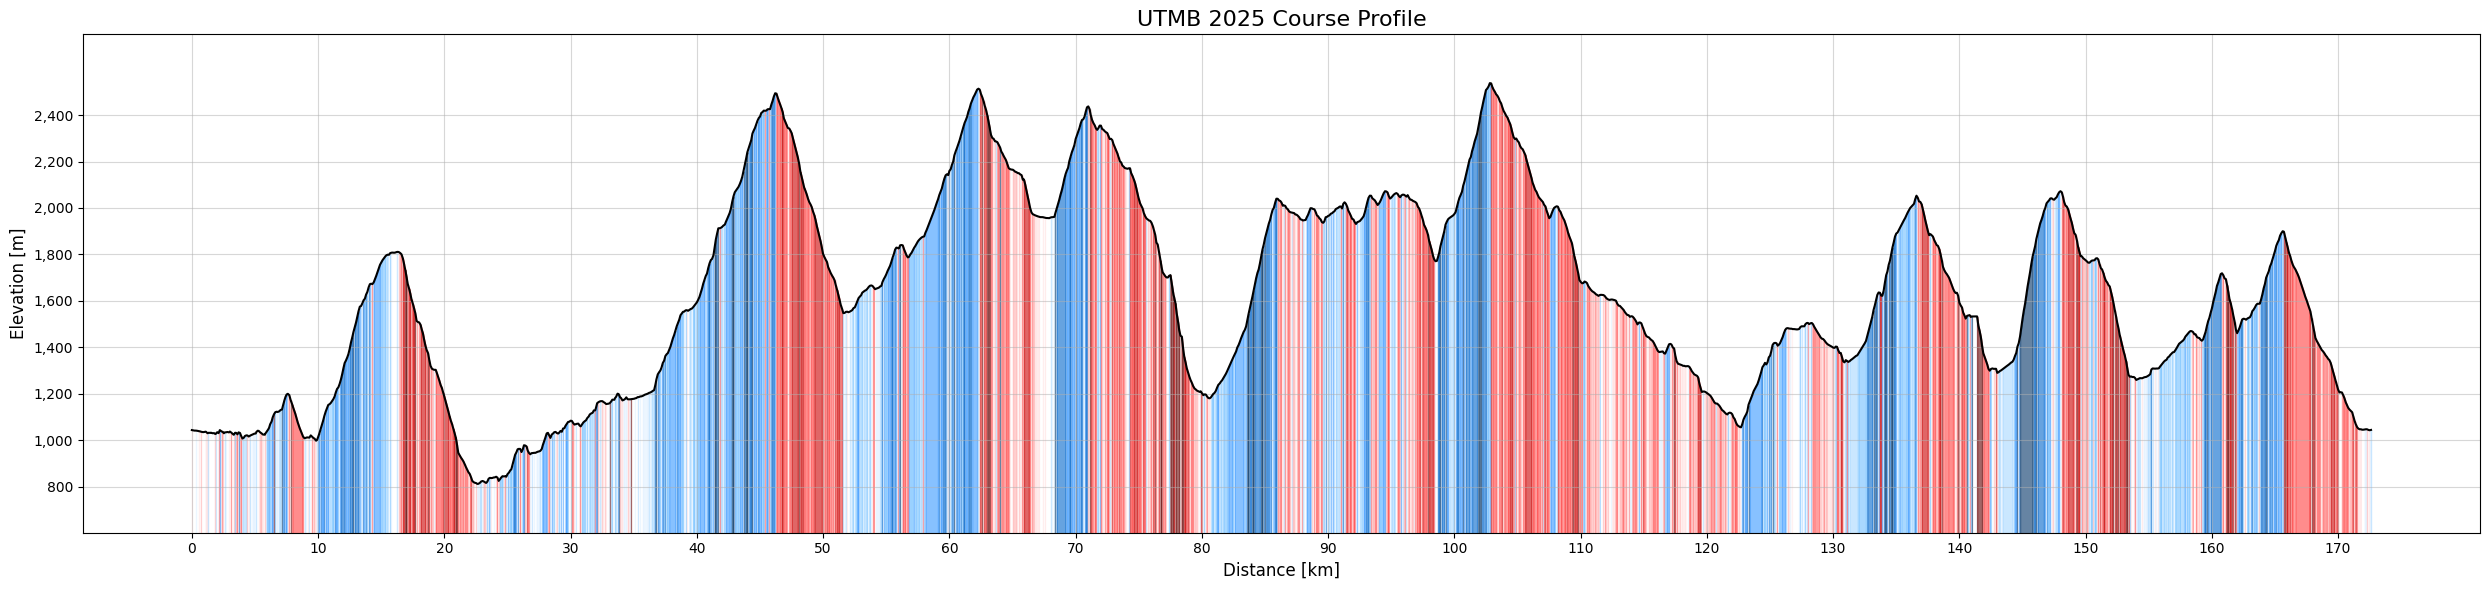

- Flat: (0, 1) % slope
- Very easy: (1, 3) % slope
- Easy: (3, 7) % slope
- Moderate: (7, 12) % slope
- Steep: (12, 20) % slope
- Very steep: (20, 30) % slope
- Extreme: (30, inf) % slope


In [ ]:
# Plot
plot_course_profile(
    gpx_tabular_df = utmb_course_df, 
    course_name = "UTMB 2025 Course Profile", 
    slope_categories = SLOPE_CATEGORIES
)

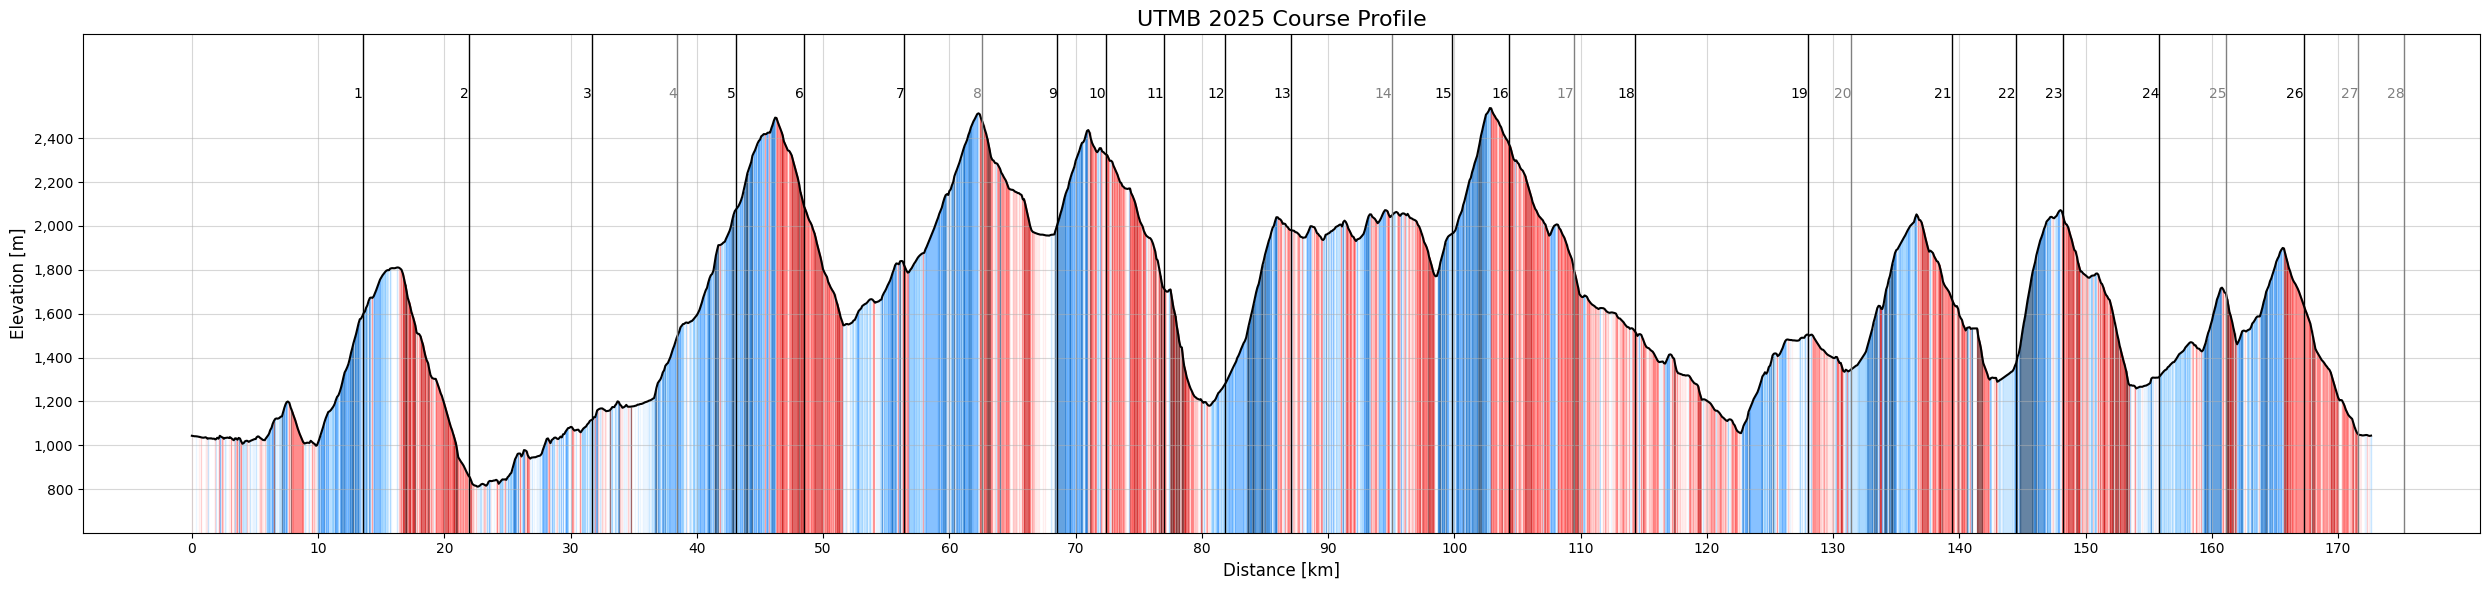

In [ ]:
# Plot course profile with checkpoints

# Checkpoints data
checkpoint_profile_df = (
    representative_sector_data_course_df
    .groupby("sector_checkpoint_id")
    .agg(
        number_of_years = ("year", "nunique"),
        checkpoint_distance_km_mean = ("sector_end_distance_km", "mean"),
        checkpoint_distance_km_min = ("sector_end_distance_km", "min"),
        checkpoint_distance_km_max = ("sector_end_distance_km", "max"),
    )
    .reset_index()
    .assign(
        checkpoint_is_common = lambda df: (
            df["number_of_years"] == representative_sector_data_course_df["year"].nunique()
        )
    )
    .sort_values("checkpoint_distance_km_mean")
    .reset_index(drop = True)
    .assign(
        checkpoint_common_number = lambda df: df["checkpoint_is_common"].cumsum(),
        checkpoint_non_common_number = lambda df: (~df["checkpoint_is_common"]).cumsum(),
        checkpoint_plot_label = lambda df: np.where(
            df["checkpoint_is_common"],
            df["checkpoint_common_number"].astype(str),
            "(" + df["checkpoint_non_common_number"].astype(str) + ")",
        ),
        checkpoint_label_y = lambda df: plot_data["elevation_m"].max() + 30 + (np.arange(len(df)) % 3) * 80,
        checkpoint_position_km_rounded = lambda df: (df["checkpoint_distance_km_mean"].round(0))
    )
)

checkpoint_plot_df = (
    checkpoint_profile_df
    .groupby("checkpoint_position_km_rounded")
    .agg(
        checkpoint_distance_km_mean = ("checkpoint_distance_km_mean", "mean"),
        checkpoint_is_common = ("checkpoint_is_common", "any"),
    )
    .reset_index()
    .sort_values("checkpoint_distance_km_mean")
    .reset_index(drop = True)
    .assign(
        checkpoint_label = lambda df: np.arange(1, len(df) + 1)
    )
)

# Plot [code from helper_functions.gpx_to_tabular.plot_course_profile]
fig, ax = plt.subplots(1,1, figsize = (25, 6))

slope_colors = {
    "Flat": "white",
    "Uphill | Very easy": "#E0F0FF",
    "Uphill | Easy": "#A8D8FF",
    "Uphill | Moderate": "#70BFFF",
    "Uphill | Steep": "#3898FF",
    "Uphill | Very steep": "#0066CC",
    "Uphill | Extreme": "#003366",
    
    "Downhill | Very easy": "#FFE0E0",
    "Downhill | Easy": "#FFB0B0",
    "Downhill | Moderate": "#FF6060",
    "Downhill | Steep": "#FF4040",
    "Downhill | Very steep": "#CC0000",
    "Downhill | Extreme": "#660000",
}

plot_data = utmb_course_df.copy()
distance_2d_100m_edges = np.arange(0, utmb_course_df["total_distance_2d_m"].max() + 110, 100)
plot_data["total_distance_2d_m_bin"] = pd.cut(plot_data["total_distance_2d_m"], bins=distance_2d_100m_edges, right=False)
plot_data = plot_data.groupby("total_distance_2d_m_bin", observed=True).aggregate({
    "total_distance_2d_m": "min",
    "elevation_m": "max",
    "slope_perc": "mean"
    })
plot_data["slope_class"] = plot_data["slope_perc"].apply(lambda s: classify_slope(s, SLOPE_CATEGORIES))

ax.set_title(f"{"UTMB 2025 Course Profile with checkpoints"}", fontsize=16)

slope_classes = plot_data["slope_class"].values
change_idx = [0] + (np.where(slope_classes[1:] != slope_classes[:-1])[0] + 1).tolist() + [len(plot_data["total_distance_2d_m"])]
for start, end in zip(change_idx[:-1], change_idx[1:]):
    sc = slope_classes[start]
    color = slope_colors.get(sc, "grey")
    ax.fill_between(plot_data["total_distance_2d_m"][start:end],  plot_data["elevation_m"][start:end], color=color, alpha=0.6)

ax.plot(plot_data["total_distance_2d_m"], plot_data["elevation_m"], color="black")

# Checkpoints
for _, row in checkpoint_plot_df.iterrows():

    checkpoint_x_m = row["checkpoint_distance_km_mean"] * 1_000
    checkpoint_color = "black" if row["checkpoint_is_common"] else "grey"

    ax.axvline(
        checkpoint_x_m,
        color = checkpoint_color,
        linestyle = "-",
        linewidth = 1,
        alpha = 1.0,
    )

    ax.text(
        checkpoint_x_m,
        plot_data["elevation_m"].max() + 30,
        str(int(row["checkpoint_label"])),
        rotation = 0,
        ha = "right",
        va = "bottom",
        fontsize = 10,
        color = checkpoint_color,
        alpha = 1.0,
    )

ax.set_xticks(np.arange(0, plot_data["total_distance_2d_m"].max() + 1, 10_000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:,.0f}"))

ax.set_yticks(np.arange(0, plot_data["elevation_m"].max() + 1, 200))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_ylim(
    plot_data["elevation_m"].min() - 0.5 * plot_data["elevation_m"].std(),
    plot_data["elevation_m"].max() + 0.8 * plot_data["elevation_m"].std(),
)

ax.set_xlabel("Distance [km]", fontsize=12)
ax.set_ylabel("Elevation [m]", fontsize=12)

plt.grid(alpha=.5)
plt.tight_layout()
plt.show()

In [9]:
# Goal time pace requirements
def _required_pace_min_km(
    length_km: float, 
    goal_time_minutes: float
) -> float:

        return goal_time_minutes / length_km

length = utmb_course_df["total_distance_2d_m"].max() / 1000
required_pace_21h = _required_pace_min_km(length, 21 * 60)


print("Required pace for Top 10 race time of {:.1f}h: {:.2f} min/km".format(21, _required_pace_min_km(length, 21 * 60)))
print("Required pace for Average race time of {:.1f}h: {:.2f} min/km".format(39, _required_pace_min_km(length, 39 * 60)))
print("Required pace for Median race time of {:.1f}h: {:.2f} min/km".format(40.5, _required_pace_min_km(length, 40.5 * 60)))
print("Required pace for Cutoff race time of {:.1f}h: {:.2f} min/km".format(46, _required_pace_min_km(length, 46 * 60)))

Required pace for Top 10 race time of 21.0h: 7.30 min/km
Required pace for Average race time of 39.0h: 13.56 min/km
Required pace for Median race time of 40.5h: 14.08 min/km
Required pace for Cutoff race time of 46.0h: 15.99 min/km
